In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r"F:\Python\Deep-Learning-and-Computer-vision\Dataset\Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop(columns=['RowNumber','CustomerId','Surname'])

In [7]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [8]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [10]:
x = df.drop(columns=['Exited'])
y = df['Exited']

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [12]:
x_train.shape

(8000, 11)

In [13]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [14]:
# import tensorflow
# from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [15]:
model = Sequential()
model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(5,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

f:\Python\Deep-Learning-and-Computer-vision\deepenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198 (792.00 B)

 Trainable params: 198 (792.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [18]:
history = model.fit(x_train_scaled,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7422 - loss: 0.6054 - val_accuracy: 0.7987 - val_loss: 0.5366
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.5073 - val_accuracy: 0.7987 - val_loss: 0.4722
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7937 - loss: 0.4647 - val_accuracy: 0.7994 - val_loss: 0.4392
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7952 - loss: 0.4434 - val_accuracy: 0.8056 - val_loss: 0.4240
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8025 - loss: 0.4304 - val_accuracy: 0.8181 - val_loss: 0.4117
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8163 - loss: 0.4174 - val_accuracy: 0.8238 - val_loss: 0.4021
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8242 - loss: 0.4042 - val_accuracy: 0.8256 - val_loss: 0.3935
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8283 - loss: 0.3933 - val_accuracy: 0.

In [19]:
model.layers[0].get_weights()  #33 weights of first layer and 3 bias of hidden layer 

[array([[ 4.37863097e-02,  2.65466422e-01, -4.93045188e-02,
          1.95029937e-02, -1.36902764e-01, -2.48996820e-02,
          2.00305834e-01,  1.31156612e-02, -1.83168296e-02,
         -4.04529840e-01, -1.95567787e-01],
        [-5.92220783e-01, -1.06057823e-01,  4.95027065e-01,
          1.27222180e-01, -3.08220834e-01, -8.65473270e-01,
         -5.99675834e-01, -5.32824814e-01,  7.32984900e-01,
         -4.33472365e-01,  2.28366908e-02],
        [-3.05686891e-01,  3.80506545e-01, -5.20113558e-02,
         -5.53378388e-02, -2.13219583e-01,  3.35377380e-02,
         -3.66621763e-01,  3.59459817e-01, -2.59709992e-02,
          2.99856216e-02,  1.57830849e-01],
        [ 1.75099686e-01, -1.50697932e-01, -5.06658137e-01,
          5.11478662e-01, -6.69198930e-01, -2.97500864e-02,
         -3.48235399e-01,  3.57454433e-03, -1.37180053e-02,
          3.94886464e-01, -3.16490717e-02],
        [-8.88858642e-03,  9.04671326e-02, -9.34858382e-01,
          1.01955330e+00, -2.69827284e-02, -

In [20]:
y_log = model.predict(x_test_scaled)
y_pred = np.where(y_log>0.5,1,0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [21]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred, y_test))

0.8375


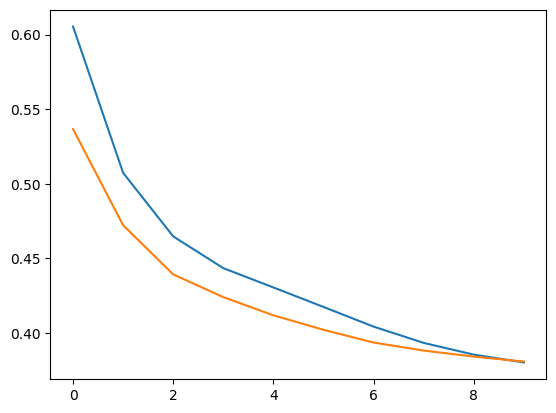

In [22]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

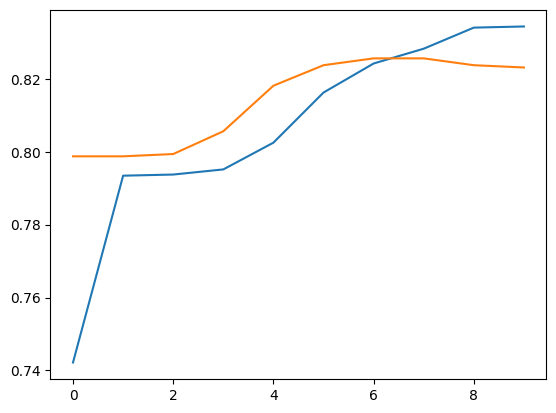

In [23]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])